# 完全手搓的波士顿房价预测

仅使用plt库用于结果绘制, 其余均仅使用py原生库实现. (包括数据导入和可能的矩阵运算)

`.ipynb`的代码分块能分段运行代码, 使得每次调试的内存占用和时间都很优.

In [41]:
import random
from typing import List
import matplotlib.pyplot as plt

In [42]:
""" 数据导入
"""

data = []
# 按行读取数据
with open("data.txt", 'r') as f:
    for l in f:
        # 按空格划分数据
        line = [float(_) for _ in l.split()]
        data.append(line)

print(f"data: {len(data)}, {len(data[0])}")
size = len(data)

data: 506, 14


In [43]:
""" 划分集
"""

# 打乱数组, 确保集划分随机
random.shuffle(data)

# 计算大小
train_size = int(size * 0.8)

# 使用切片划分
train = data[:train_size]
test = data[train_size:]

print(f"train: {len(train)}, test: {len(test)}")


train: 404, test: 102


In [44]:
""" 数据标准化
"""

# 计算均值
mean = [sum(_)/14 for _ in zip(*train)]

# 更新train和test
for row in range(len(train)):
    train[row] = [train[row][_] / mean[_] for _ in range(14)]

for row in range(len(test)):
    test[row] = [test[row][_] / mean[_] for _ in range(14)]


In [45]:
""" 设置参数和函数
"""

# 初始化参数
# lambda_1, lambda_2, ..., lambda_13, delta
para = [1 for _ in range(14)]

# 设置特征值(前13个变量)和目标值(最后一个变量)
features = [sample[:-1] for sample in train]
targets = [sample[-1] for sample in train]

# 设置线性回归函数
# y = lambda_1 x_1 + lambda_2 x_2 + ... + lambda_13 x_13 + delta
def y(x: List[float], para: List[float]) -> float:
    return sum([para[_] * x[_] for _ in range(13)]) + para[13]

# 设置残差平方和函数
# r = y_真 - y_估, rss = r_1^2 + r_2^2 + ...
def rss(y_pred: List[float], y_true: List[float]):
    return sum([(y_pred[_] - y_true[_])**2 for _ in range(len(y_pred))])


# 测试函数(在当前[1, 1, ..., 1]参数下计算残差平方和)
y_pred = [y(feature, para) for feature in features]
print(rss(y_pred, targets))

822.189418806235


# 计算梯度

线性回归函数:

$$
y = \lambda_1 x_1 + \lambda_2 x_2 + \cdots + \lambda_13 x_13 + \delta
$$

残差平方和函数:

$$
\begin{aligned}
rss = \sum_{i = 1}^n (y_i - \hat{y}_i)^2
\end{aligned}
$$

则对于 $\lambda$ , 其偏导数为:

$$
\begin{aligned}
\frac{\partial rss}{\partial \lambda_i}
& = \frac{\partial}{\partial \lambda_i} (\sum_{i = 1}^n (y_i - \hat{y}_i)^2) \\
& = 2 \sum_{i = 1}^n (y_i - \hat{y}_i) \cdot \frac{\partial}{\partial \lambda_i} (y_i - \hat{y}_i) \\
& = - 2 \sum_{i = 1}^n (y_i - \hat{y}_i) \cdot \frac{\partial \hat{y}_i}{\partial \lambda_i} \\
& = - 2 \sum_{i = 1}^n (y_i - \hat{y}_i) \cdot x_{ij}
\end{aligned}
$$

对于 $\delta$ , 其偏导数为:

$$
\begin{aligned}
\frac{\partial rss}{\partial \delta}
& = \frac{\partial}{\partial \delta} (\sum_{i = 1}^n (y_i - \hat{y}_i)^2) \\
& = 2 \sum_{i = 1}^n (y_i - \hat{y}_i) \cdot \frac{\partial}{\partial \delta} (y_i - \hat{y}_i) \\
& = - 2 \sum_{i = 1}^n (y_i - \hat{y}_i) \cdot \frac{\partial \hat{y}_i}{\partial \delta} \\
& = - 2 \sum_{i = 1}^n (y_i - \hat{y}_i)
\end{aligned}
$$

In [46]:
""" 梯度计算
"""

# 计算方法见上述MarkDown
def get_gradient(features, targets, para):
    # 计算残差
    r = [y(feature, para) - target for feature, target in zip(features, targets)]
    # 初始化梯度
    gradient = [0 for _ in range(14)]

    # 计算lambda偏导
    for i in range(13):
        gradient[i] = sum([r[_] * features[_][i] for _ in range(len(targets))])
    
    # 计算delta偏导
    gradient[13] = sum(r)

    return gradient

# 测试函数
print(get_gradient(features, targets, para))

[23.3468870795715, 20.2093293537524, 20.437571240269815, 25.06906176136894, 20.025465641461217, 19.782848735473856, 20.14593462753977, 19.477329268728123, 21.053160971743957, 20.359235246515915, 19.866028063672356, 19.6617769939876, 20.33991823995711, 572.0]


经过多次试验, 发现该数据线性质量相当差. 在`max_itr`小于`10000`时, `tolerance`连`1`都达不到.

~~因此决定存储每一次的运行结果, 在达到`max_itr`情况下计算存储的结果, 返回最优解.(占用过大而废弃)~~

因此存储`itr`次计算后的最佳运行结果, 在达到`max_itr`情况下返回已经得到的最优解.

In [47]:
""" 梯度下降
"""

# 梯度下降函数
# 超参数设置: 
# learning_rate  学习率, 每次更新参数的长度
# tolerance      容差, 最终精度
# max_itr        迭代次数上限
def gradient_descent(features, targets, para, learning_rate, tolerance, max_itr):
    # 存储每次的运行结果(内存再见~)
    best_result = [*[0 for _ in range(14)], float("inf")]
    
    # 迭代
    for itr in range(max_itr):
        # 计算梯度
        gradient = get_gradient(features, targets, para)
        
        # 检测是否达到精度
        if all(abs(_) < tolerance for _ in gradient):
            print(f"Done! Itr: {itr}")
            return para
        
        # 参数梯度下降
        para = [para[_] - learning_rate * gradient[_] for _ in range(len(para))]

        y_pred = [y(_, para) for _ in features]
        if rss(y_pred, targets) < best_result[-1]:
            best_result = [*para, rss(y_pred, targets)]

    print(f"Can't keep up!")

    # 获取最优情况
    return best_result[:-1]


一组可以成功运算的超参数: 
learning_rate = 0.0001
tolerance = 1
max_itr = 5000

In [48]:
""" 应用
"""

# 设置超参数
learning_rate = 0.0001
tolerance = 0.1
max_itr = 50000

# 开始运行
optimized_para = gradient_descent(features, targets, para, learning_rate, tolerance, max_itr)
print(f"Optimized Para: {optimized_para}")
y_pred_optimized = [y(_, optimized_para) for _ in features]
print("Optimized RSS:", rss(y_pred_optimized, targets))

Done! Itr: 38622
Optimized Para: [-0.14036219987325105, 0.11376690194243057, 0.36387755559112356, 0.028399797825742458, 0.7928008516999817, 1.0412548813234948, 0.661830873261306, 0.9899110571658188, 0.04090162673778539, 0.46473143697745817, 0.880772358618977, 1.0289884182893352, 0.30174138852299326, -0.1930052163770912]
Optimized RSS: 0.25547814671259705


In [49]:
""" 测试结果
"""

# 遍历测试集
y_test_pred = [y(_, optimized_para) for _ in test]
test_rss = rss(y_test_pred, [_[-1] for _ in test])

print(f"Test RSS: {test_rss}")

Test RSS: 0.06375837722719913


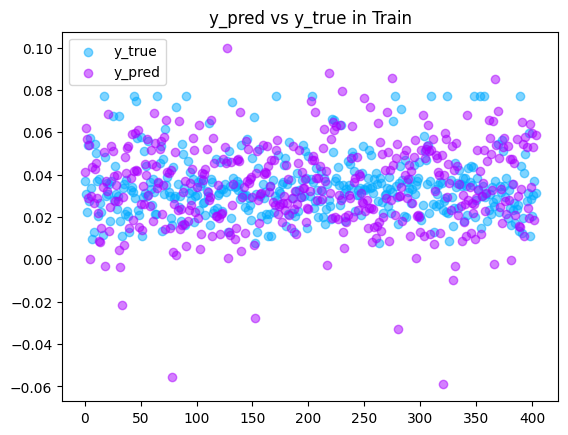

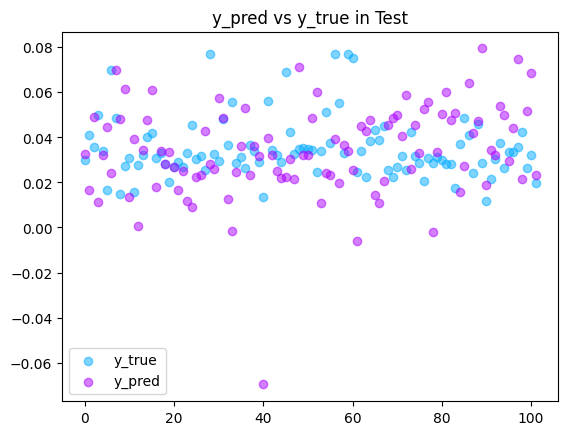

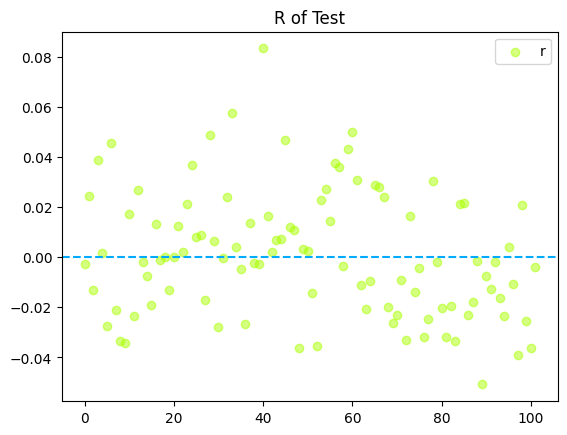

In [50]:
""" 数据分析
"""

# 本程序唯一使用第三方库之处
# 训练集预测值与实际值
plt.title(f"y_pred vs y_true in Train")
plt.scatter(range(len(train)), targets, label="y_true", color="#00aaff", alpha=0.5)
plt.scatter(range(len(train)), y_pred_optimized, label="y_pred", color="#aa00ff", alpha=0.5)
plt.legend()
plt.show()

# 测试集预测值与实际值
plt.title(f"y_pred vs y_true in Test")
plt.scatter(range(len(test)), [_[-1] for _ in test], label="y_true", color="#00aaff", alpha=0.5)
plt.scatter(range(len(test)), y_test_pred, label="y_pred", color="#aa00ff", alpha=0.5)
plt.legend()
plt.show()

# 测试集残差
plt.title(f"R of Test")
plt.scatter(range(len(test)), [test[_][-1] - y_test_pred[_] for _ in range(len(test))], label="r", color="#aaff00", alpha=0.5)
plt.axhline(y=0, color="#00aaff", linestyle="--")
plt.legend()
plt.show()